---

# Gera Arquivo Netcdf de Densidade de Focos de Calor do INPE para o Brasil com Dados do Satélite de Referência

---

- `OBJETIVO`:
> Este código acumula numa grade de 20km os focos de calor por ano, separados por tempo de 2003 à 2025.


- `DADOS DE ENTRADA`:
> Arquivo CSV de focos de calor anual do satélite de referência fornecido pelo INPE. O arquivo nectdf foi criado utilizando os focos de calor disponibilizados pelo [INPE](https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref/) do Satélite de referência AQUA de 2003 à 2024.


- `DADOS DE SAÍDA`:
> Arquivo netcdf de focos de calor interpolados para uma grade de 20km para o Brasil. Acesso ao [arquivo](https://github.com/evmpython/000_CODIGOS_REFERENCIA/blob/main/07_TESTE_MANN_KENDALL/input/focos_anuais_brasil_20km_AQUA_2003_2025.nc). O arquivo nectdf foi criado utilizando os focos de calor disponibilizados pelo [INPE](https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref/) do Satélite de referência AQUA de 2003 à 2024.


- `OBSERVAÇÕES`:
   > Nenhuma.

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---

# Preparando o ambiente

In [1]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import ultraplot as uplt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import os
import imageio
import glob
import calendar
import pandas as pd
import glob
import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings("ignore")

# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL'

# diretório de entrada
dir_input = f'{dir}/output/01_focos_raw'

# diretório de saída
dir_output = f'{dir}/output/02_netcdf_focos_por_ano'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.4 MB/s eta 0:00:00
Mounted at /content/drive


# Função

In [2]:
# Função que calcula o índice i e j da localização do foco
def index(longitudes_matriz, latitudes_matriz, lon_foco, lat_foco):

    ''' Função para calcular o índice (i e j) do pixel de uma matriz que o relâmpago pertence

    Parâmetros:
               longitudes_matriz (array): array de uma dimensão das longitudes da matriz em graus
               latitudes_matriz (array): array de uma dimensão das latitudes da matriz em graus
               lon_raio (float): valor da longitude do foco em graus
               lat_raio (float): valor da latitude do foco em graus

    Retorna:
            indice_lat_raio (float): índice da latitude (ou seja, da linha) do pixel da matriz que o foco pertence
            indice_lon_raio (float): índice da longitude (ou seja, da coluna) do pixel da matriz que o foco pertence
    '''

    # calcula a diferença entre as lats/lons da matriz e a latitude/longitude do foco
    distancia_lon = (longitudes_matriz - lon_foco)**2
    distancia_lat = (latitudes_matriz - lat_foco)**2

    # índice da longitude e latitude do foco
    indice_lon_foco = np.nonzero(distancia_lon == np.min(distancia_lon))
    indice_lat_foco  = np.nonzero(distancia_lat == np.min(distancia_lat))

    # retorna os valores dos índices calculados
    return indice_lat_foco, indice_lon_foco

# Leitura dos dados

In [4]:
# cria uma tabela
df_2003_a_2025 = pd.DataFrame()

# lista os arquivos mensais do ano atual
files = sorted(glob.glob(f'{dir_input}/focos_br_ref_*')) # focos_br_ref_2003.zip

# loop de cada arquivo da lista files
for file in files:

    print('LENDO ARQUIVO ===>>>', file)

    # leitura da tabela
    df0 = pd.read_csv(file, compression='zip')

    # junta a tabela que foi lida com a anterior
    df_2003_a_2025 = pd.concat([df_2003_a_2025, df0], ignore_index=True)

# remove colunas
df_2003_a_2025.drop(['id_bdq','foco_id','pais'], axis=1, inplace=True)

# renomeia coluna
df_2003_a_2025.rename(columns={'data_pas': 'data'}, inplace=True)

# reposiciona as colunas
df_2003_a_2025 = df_2003_a_2025[['data','lat','lon','municipio','estado','bioma']]

# transforma a coluna "datahora" para o formato "datetime"
df_2003_a_2025['data'] = pd.to_datetime(df_2003_a_2025['data'])

# seta a coluna "datahora" como o índice da tabela
df_2003_a_2025.set_index('data', inplace=True)

# ordena a tabela pelo índice
df_2003_a_2025.sort_index(inplace=True)

LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2003.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2004.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2005.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2006.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2007.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output/01_focos_raw/focos_br_ref_2008.zip
LENDO ARQUIVO ===>>> /content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/07_TESTE_MANN_KENDALL/output

In [5]:
# mostra o dataframe final
df_2003_a_2025

,lat,lon,municipio,estado,bioma
data,,,,,
2003-01-01 16:04:00,-14.82900,-40.13300,NOVA CANAÃ,BAHIA,Mata Atlântica
2003-01-01 16:04:00,-15.62100,-41.66500,BERIZAL,MINAS GERAIS,Mata Atlântica
2003-01-01 16:04:00,-15.27600,-41.51400,TREMEDAL,BAHIA,Mata Atlântica
2003-01-01 16:05:00,-10.11100,-36.50500,IGREJA NOVA,ALAGOAS,Caatinga
2003-01-01 16:05:00,-11.88600,-37.81500,ESPLANADA,BAHIA,Mata Atlântica
...,...,...,...,...,...
2025-12-31 18:36:00,0.69087,-60.36650,RORAINÓPOLIS,RORAIMA,Amazônia
2025-12-31 18:36:00,-0.09348,-51.28310,MAZAGÃO,AMAPÁ,Amazônia
2025-12-31 18:36:00,0.68670,-60.35904,RORAINÓPOLIS,RORAIMA,Amazônia


# Gera todos os anos num único arquivo netcdf

In [6]:
%%time
# Limites do Brasil
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0

# Espaçamento da grade em graus
delta = 20/100.   # grade com 20 km de resolução espacial

# Montando a grade
lons = np.arange(lonmin, lonmax, delta)
lats = np.arange(latmax, latmin, -delta)

# Quantidade de pontos para longitude e latitude
nlon = len(lons)
nlat = len(lats)

# Inicializa a lista para armazenar as matrizes de focos anuais
focos_anuais = []

# ano inicial e final
ano_inicio, ano_final_exclusivo = 2003, 2026 # Loop will run for years 2003, 2004, 2005

# Loop dos anos
for ano in np.arange(ano_inicio, ano_final_exclusivo):

    print('Processando ===>>>', ano)

    # seleciona o mês
    df_selec = df_2003_a_2025.loc[f'{str(ano)}']

    # gera matriz de raios
    focos_lon, focos_lat = df_selec['lon'].values, df_selec['lat'].values

    # interpolando para ponto de grade
    focos = np.zeros((nlat, nlon))

    # loop em cada longitude e latitude da lista
    for lonfoco, latfoco in zip(focos_lon, focos_lat):

        # função que extrai a qual pixel aquele relâmpago pertence
        lin, col = index(lons, lats, lonfoco, latfoco)

        # soma os relâmpagos por pixel
        focos[lin,col]+=1

    # appenda a matriz de focos
    focos_anuais.append(focos)

# Empilhar ao longo da dimensão time
focos_3d = np.stack(focos_anuais, axis=0)  # shape: (n_anos, nlat, nlon)

# Criar coordenada time com todos os anos
tempos = pd.date_range(start=f'{str(ano_inicio)}-01-01', end=f'{str(ano_final_exclusivo-1)}-01-01', freq='YS')

# Salvar arquivo único com compressão
data_vars = {'focos': (('time', 'lat', 'lon'), focos_3d,
                        {'units': 'ocorrências/400km²', 'long_name':'Focos de Calor'})} # Removed encoding parameters from here

coords = {'lat': lats, 'lon': lons, 'time': tempos}
ds = xr.Dataset(data_vars=data_vars, coords=coords)

# Opção 1: Compressão básica
ds.to_netcdf(f'{dir_output}/focos_anuais_brasil_20km_AQUA_{str(ano_inicio)}_{str(ano_final_exclusivo-1)}.nc', encoding={'focos': {'zlib': True, 'complevel': 5, 'shuffle': True, 'dtype': 'int32'}})

Processando ===>>> 2003
Processando ===>>> 2004
Processando ===>>> 2005
Processando ===>>> 2006
Processando ===>>> 2007
Processando ===>>> 2008
Processando ===>>> 2009
Processando ===>>> 2010
Processando ===>>> 2011
Processando ===>>> 2012
Processando ===>>> 2013
Processando ===>>> 2014
Processando ===>>> 2015
Processando ===>>> 2016
Processando ===>>> 2017
Processando ===>>> 2018
Processando ===>>> 2019
Processando ===>>> 2020
Processando ===>>> 2021
Processando ===>>> 2022
Processando ===>>> 2023
Processando ===>>> 2024
Processando ===>>> 2025
CPU times: user 3min 34s, sys: 591 ms, total: 3min 34s
Wall time: 3min 41s


In [7]:
ds_combinado = xr.open_dataset(f'{dir_output}/focos_anuais_brasil_20km_AQUA_{str(ano_inicio)}_{str(ano_final_exclusivo-1)}.nc')
ds_combinado

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 23, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 184B 2003-01-01 2004-01-01 ... 2025-01-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (time, lat, lon) int32 4MB ...

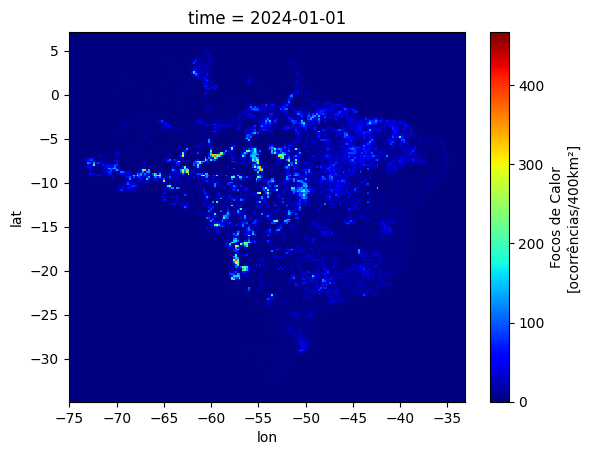

In [8]:
ds_combinado['focos'].sel(time='2024').plot(cmap='jet')